In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
import pandas as pd

import numpy as np

import math

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

C:\Users\ADMIN\.conda\envs\cvenv2\Lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [46]:
df = pd.read_csv('data/train.csv')
df.columns

Index(['id', 'age', 'gender', 'course', 'study_hours', 'class_attendance',
       'internet_access', 'sleep_hours', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')

In [3]:
df_submission = pd.read_csv('data/sample_submission.csv')
df_submission.columns

Index(['id', 'exam_score'], dtype='object')

In [4]:
table_describe = df.describe(include='all').T
table_describe['dtypes'] = df.dtypes
table_describe['unique_count'] = df.nunique()
table_describe

,count,unique,top,freq,mean,std,min,25%,50%,75%,max,dtypes,unique_count
id,630000.0,NaN,NaN,NaN,314999.5,181865.479132,0.0,157499.75,314999.5,472499.25,629999.0,int64,630000
age,630000.0,NaN,NaN,NaN,20.545821,2.260238,17.0,19.0,21.0,23.0,24.0,int64,8
gender,630000,3,other,211097,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object,3
course,630000,7,b.tech,131236,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object,7
study_hours,630000.0,NaN,NaN,NaN,4.002337,2.35988,0.08,1.97,4.0,6.05,7.91,float64,792
class_attendance,630000.0,NaN,NaN,NaN,71.987261,17.430098,40.6,57.0,72.6,87.2,99.4,float64,617
internet_access,630000,2,yes,579423,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object,2
sleep_hours,630000.0,NaN,NaN,NaN,7.072758,1.744811,4.1,5.6,7.1,8.6,9.9,float64,66
sleep_quality,630000,3,poor,213675,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object,3
study_method,630000,5,coaching,131697,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object,5


In [5]:
df.sample(frac=.1, random_state=None).head(50)

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
347053,347053,18,female,b.sc,0.32,97.1,no,5.0,poor,group study,medium,moderate,30.600
50254,50254,18,other,bca,0.89,53.5,yes,5.9,average,self-study,high,moderate,48.400
435534,435534,18,male,diploma,0.16,94.5,yes,8.4,good,group study,medium,moderate,51.900
192021,192021,24,other,b.tech,2.49,52.7,yes,8.3,poor,coaching,high,easy,37.600
60714,60714,20,other,bba,7.08,59.3,yes,6.0,poor,mixed,high,moderate,76.400
328811,328811,20,male,bba,3.54,80.3,yes,8.2,good,mixed,low,easy,63.700
144640,144640,19,other,b.tech,0.08,85.0,yes,8.0,poor,self-study,high,easy,45.200
622128,622128,18,female,diploma,1.73,73.2,no,8.2,good,mixed,low,easy,55.300
25153,25153,18,other,b.tech,5.37,77.3,yes,9.0,poor,coaching,high,hard,57.400
601774,601774,21,other,b.sc,1.66,90.7,yes,7.7,good,coaching,high,hard,66.900


In [6]:
num_cols = ['age', 'study_hours', 'class_attendance', 'sleep_hours'] # Standardization
one_hot_cat_cols = ['gender', 'course', 'internet_access', 'study_method']
ordinal_cat_cols = ['sleep_quality', 'facility_rating', 'exam_difficulty']
sleep_quality_orders = ['poor', 'average', 'good']
facility_rating_orders = ['low', 'medium', 'high']
exam_difficulty_orders = ['easy', 'moderate', 'hard']

In [7]:
label = 'exam_score'
bins = [0, 40, 70, 100]
labels = ['low', 'moderate', 'high']
df['score_type'] = pd.cut(df[label], bins=bins, labels=labels)

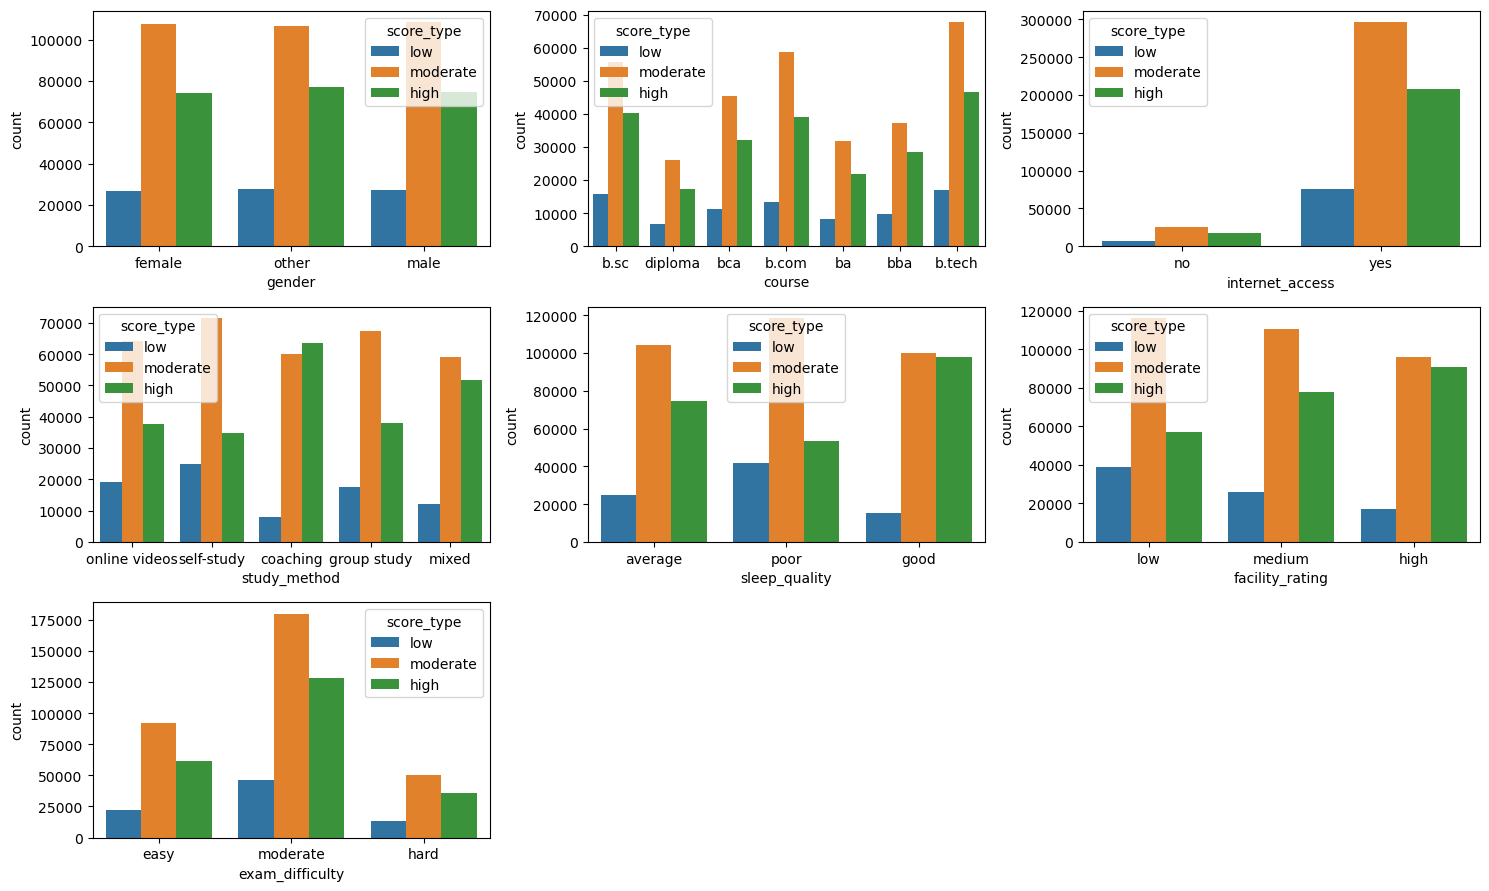

In [8]:
cat_cols = one_hot_cat_cols + ordinal_cat_cols
graph_num = len(cat_cols)
n_cols = 3
n_rows = math.ceil(graph_num / n_cols)

fig, axis = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))

axis = axis.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(df, x=col, hue='score_type', ax=axis[i])


for i in range(graph_num, n_cols * n_rows):
    fig.delaxes(axis[i])


plt.tight_layout()
plt.show()

In [47]:
df.drop(['id', 'score_type'], axis=1, inplace=True, errors='ignore')

In [39]:
ct = ColumnTransformer(transformers=[
        ('onehot', OneHotEncoder(drop='first'), one_hot_cat_cols),
        ('ordinal', OrdinalEncoder(categories=[sleep_quality_orders, facility_rating_orders, exam_difficulty_orders]), ordinal_cat_cols),
        ('standard', StandardScaler(), num_cols)
    ], remainder='passthrough')

df_transformed = pd.DataFrame(ct.fit_transform(df), columns=ct.get_feature_names_out())
df_transformed.head(5)

,onehot__gender_male,onehot__gender_other,onehot__course_b.sc,onehot__course_b.tech,onehot__course_ba,onehot__course_bba,onehot__course_bca,onehot__course_diploma,onehot__internet_access_yes,onehot__study_method_group study,...,onehot__study_method_online videos,onehot__study_method_self-study,ordinal__sleep_quality,ordinal__facility_rating,ordinal__exam_difficulty,standard__age,standard__study_hours,standard__class_attendance,standard__sleep_hours,remainder__exam_score
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.200943,1.655875,1.538302,-1.245269,78.3
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,1.0,1.0,-1.126352,0.401573,1.308814,-1.359895,46.7
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,2.0,1.0,-0.241488,0.287160,1.182595,-0.729454,99.0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,1.0,2.0,1.0,-0.683920,-0.848492,-1.290141,0.703367,63.9
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,2.0,2.0,0.0,1.085807,1.545699,0.855575,1.448434,100.0


## Linear Regression

In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error

X = df_transformed.drop('remainder__exam_score', axis=1)
y = df[label]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

coef = pd.DataFrame({
    "coef": model.coef_
}, index=X.columns)
coef["flag"] = np.where(abs(coef["coef"]) < 0.5, "⚠ small", "")
coef

MSE: 78.55155906405007
MAE: 7.071523115106723
RMSE: 8.862931742039429
R2: 0.7790665707982773


,coef,flag
onehot__gender_male,-0.115523,⚠ small
onehot__gender_other,0.191533,⚠ small
onehot__course_b.sc,-0.171391,⚠ small
onehot__course_b.tech,0.183454,⚠ small
onehot__course_ba,-0.035734,⚠ small
onehot__course_bba,0.240677,⚠ small
onehot__course_bca,0.024818,⚠ small
onehot__course_diploma,0.192411,⚠ small
onehot__internet_access_yes,-0.006372,⚠ small
onehot__study_method_group study,-7.246263,


# SGDRegressor

In [49]:
from sklearn.linear_model import SGDRegressor

sgd_model = Pipeline([
    ("pre", ct),
    ("sgd", SGDRegressor(
        loss="squared_error",
        penalty="l2",
        alpha=0.0001,
        learning_rate="optimal",
        max_iter=1000,
        tol=1e-3,
        random_state=42
    ))
])

X = df.drop(label, axis=1)
y = df[label]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

sgd_model.fit(X_train, y_train)

preds = sgd_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 8.873753579664474
R2: 0.7785267121056851


# Neural Network

In [12]:
# Create dataset class
class RegressionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [53]:
# prepare data loaders
train_dataset = RegressionDataset(X_train.values, y_train.values)
test_dataset = RegressionDataset(X_test.values, y_test.values)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [54]:
# Neural network architecture (Funnel shape to help the model compress information into the most useful representation)
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.2):
        super().__init__()

        self.fc1 = nn.Linear(dim, dim)
        self.bn1 = nn.BatchNorm1d(dim)

        self.fc2 = nn.Linear(dim, dim)
        self.bn2 = nn.BatchNorm1d(dim)

        self.dropout = nn.Dropout1d(dim)

    def forward(self, x):
        residual = x

        out = self.bn1(self.fc1(x))

        out = self.bn2(self.fc2(out))

        out = out + residual
        
        return out


class CatNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__(self)

        self.fc1 = nn.Linear(input_dim, 64),
        self.bn1 = nn.BatchNorm1d(),
        self.

    def forward(self, X):
        return self.model(X)

In [55]:
# Hyper parameter config
input_dim = X_train.shape[1]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RegressionNet(input_dim).to('cuda')
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [56]:
epochs = 30

def evaluate(model, loader):

    model.eval()
    loss_total = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch)
            loss = criterion(preds, y_batch)

            loss_total += loss.item()

    return loss_total / len(loader)

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    val_loss = evaluate(model, test_loader)

    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

C:\Users\ADMIN\.conda\envs\cvenv2\Lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
C:\Users\ADMIN\.conda\envs\cvenv2\Lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([24])) that is different to the input size (torch.Size([24, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 0 | Train Loss: 491.9765 | Val Loss: 365.0159
Epoch 10 | Train Loss: 357.9711 | Val Loss: 355.3296
Epoch 20 | Train Loss: 357.9692 | Val Loss: 355.5668


# LightGBM

In [19]:
import lightgbm as lgb

train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_test, label=y_test)

In [20]:
params = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",

    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": -1,

    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,

    "verbose": -1
}

In [21]:
# Training
model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[val_data],
    callbacks=[
        lgb.early_stopping(50),
        lgb.log_evaluation(50)
    ]
)

Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 9.45678
[100]	valid_0's rmse: 8.84411
[150]	valid_0's rmse: 8.78082
[200]	valid_0's rmse: 8.76576
[250]	valid_0's rmse: 8.75737
[300]	valid_0's rmse: 8.75115
[350]	valid_0's rmse: 8.74557
[400]	valid_0's rmse: 8.74072
[450]	valid_0's rmse: 8.73774
[500]	valid_0's rmse: 8.73509
[550]	valid_0's rmse: 8.73148
[600]	valid_0's rmse: 8.72972
[650]	valid_0's rmse: 8.72705
[700]	valid_0's rmse: 8.7251
[750]	valid_0's rmse: 8.72349
[800]	valid_0's rmse: 8.72175
[850]	valid_0's rmse: 8.72014
[900]	valid_0's rmse: 8.71898
[950]	valid_0's rmse: 8.71808
[1000]	valid_0's rmse: 8.71731
Did not meet early stopping. Best iteration is:
[1000]	valid_0's rmse: 8.71731


In [23]:
preds = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("RMSE:", rmse)

RMSE: 8.717307259961725


In [24]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importance()
}).sort_values("importance", ascending=False)

print(importance.head(10))

                               feature  importance
17               standard__study_hours        7501
18          standard__class_attendance        6781
19               standard__sleep_hours        4552
16                       standard__age        1873
13              ordinal__sleep_quality        1558
14            ordinal__facility_rating        1441
12     onehot__study_method_self-study         774
15            ordinal__exam_difficulty         757
11  onehot__study_method_online videos         697
9     onehot__study_method_group study         639


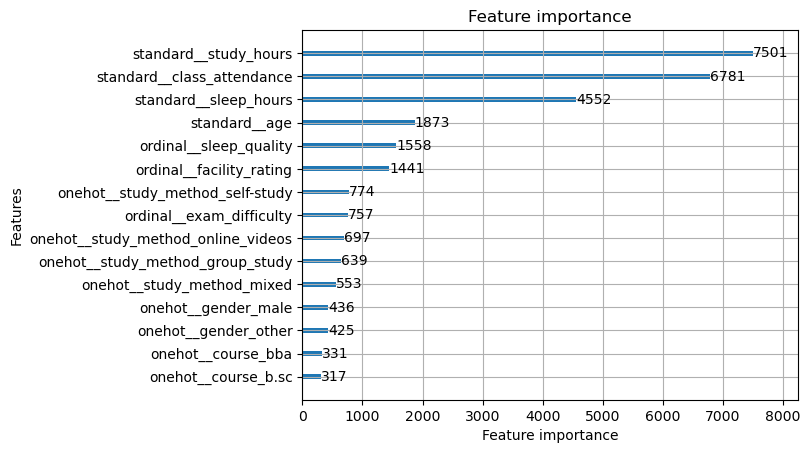

In [25]:
import matplotlib.pyplot as plt

lgb.plot_importance(model, max_num_features=15)
plt.show()